<a href="https://colab.research.google.com/github/remideso/remideso.github.io/blob/main/BeltLine_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/remideso/remideso.github.io/blob/main/BeltLine_Machine_Learning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# **Machine Learning & Predictive Modeling**
## **Tracks of Change: Race, Space, and the Atlanta BeltLine**

This notebook builds on my capstone project about the Atlanta BeltLine, housing costs, and racial composition.

In my previous statistical analysis notebook, I looked at the health of the dataset through EDA, hypothesis testing, correlation analysis, OLS regression, multicollinearity checks, missing values, and class balance.

For this assignment, I use the cleaned data to build predictive models.

Because my capstone originally used linear regression to understand rent, this notebook uses **regression as the main model type**. I also include a classification section as a second predictive angle so I can evaluate both continuous and categorical outcomes.


# **Research Question**

Can neighborhood-level demographic, economic, spatial, and time-based features predict rent pressure around the Atlanta BeltLine?

More specifically, I ask:

1. Can these features predict actual median gross rent?
2. Can these features classify whether a tract is high-rent compared to other tracts in the same year?
3. Which features drive the predictions the most?


# **Modeling Approach**

This notebook uses two types of predictive modeling:

## 1. Regression Model
The main model predicts actual `median_gross_rent`.

This is most aligned with my capstone because my original statistical model used linear regression to understand what factors are related to rent.

Regression metrics used:
- RMSE
- MAE
- R²

## 2. Classification Model
The second model predicts whether a tract is high-rent within its own year.

I created `high_rent_within_year` instead of just using the overall median rent. This is important because rent naturally increased from 2000 to 2020. If I used one overall cutoff, the model could mostly learn that 2020 tracts are high-rent and 2000 tracts are low-rent. Using the year-specific median makes the classification task fairer.

Classification metrics used:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC
- Confusion Matrix


In [1]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing and train/test split
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# evaluation
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# load dataset directly from github

df = pd.read_csv('https://raw.githubusercontent.com/remideso/remideso.github.io/main/atlanta_spatial_final.csv')

df.head()

,tract_id,tract_name,total_pop,median_income,median_home_value,median_gross_rent,occupied_units,owner_units,renter_units,hispanic_pop,white_pop,black_pop,poverty_universe,below_poverty,poverty_rate,year,centroid_distance_miles,beltline_half_mile,beltline_one_mile,beltline_three_miles,pct_white,pct_black,pct_hispanic,pct_renter
0,13089020100,"Census Tract 201, DeKalb County, Georgia",1783.0,96542.0,372400.0,808.0,759,546,213,192.0,1500.0,41.0,1782.0,84.0,0.047138,2000,1.533807,0.0,0.0,1.0,0.841279,0.022995,0.107684,0.280632
1,13089020200,"Census Tract 202, DeKalb County, Georgia",2198.0,56094.0,438100.0,730.0,1255,528,727,68.0,1907.0,132.0,2182.0,140.0,0.064161,2000,1.297543,0.0,0.0,1.0,0.867607,0.060055,0.030937,0.579283
2,13089020300,"Census Tract 203, DeKalb County, Georgia",3257.0,73715.0,260500.0,691.0,1510,1025,485,72.0,2540.0,490.0,3253.0,321.0,0.098678,2000,1.724488,0.0,0.0,1.0,0.779859,0.150445,0.022106,0.321192
3,13089020400,"Census Tract 204, DeKalb County, Georgia",2124.0,47438.0,259500.0,729.0,1166,561,605,71.0,1856.0,120.0,2137.0,147.0,0.068788,2000,0.880254,0.0,1.0,1.0,0.873823,0.056497,0.033427,0.518868
4,13089020500,"Census Tract 205, DeKalb County, Georgia",3203.0,28147.0,84200.0,530.0,1183,579,604,94.0,232.0,2833.0,3263.0,857.0,0.262642,2000,0.889622,0.0,1.0,1.0,0.072432,0.884483,0.029347,0.510566


In [3]:
# check dataset size

df.shape

(854, 24)

In [4]:
# check columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 854 entries, 0 to 853
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tract_id                 854 non-null    int64  
 1   tract_name               854 non-null    object 
 2   total_pop                854 non-null    float64
 3   median_income            837 non-null    float64
 4   median_home_value        819 non-null    float64
 5   median_gross_rent        799 non-null    float64
 6   occupied_units           854 non-null    int64  
 7   owner_units              854 non-null    int64  
 8   renter_units             854 non-null    int64  
 9   hispanic_pop             854 non-null    float64
 10  white_pop                854 non-null    float64
 11  black_pop                854 non-null    float64
 12  poverty_universe         851 non-null    float64
 13  below_poverty            851 non-null    float64
 14  poverty_rate             8

# **1. Data Preparation**

This section implements the fixes from the statistics notebook:

- use a cleaner feature set to reduce multicollinearity
- remove rows missing the regression target
- create distance groups
- treat year as categorical
- scale numerical features
- one-hot encode categorical features
- impute missing feature values inside the pipeline
- strictly separate train and test data


In [5]:
# create distance groups

bins = [0, 0.5, 1, 1.5, 3, 5, 10, np.inf]

labels = [
    '0-0.5 miles',
    '0.5-1 mile',
    '1-1.5 miles',
    '1.5-3 miles',
    '3-5 miles',
    '5-10 miles',
    '10+ miles'
]

df['distance_group'] = pd.cut(
    df['centroid_distance_miles'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# treating year as categorical
df['year_cat'] = df['year'].astype(str)

df[['year', 'year_cat', 'centroid_distance_miles', 'distance_group']].head()

,year,year_cat,centroid_distance_miles,distance_group
0,2000,2000,1.533807,1.5-3 miles
1,2000,2000,1.297543,1-1.5 miles
2,2000,2000,1.724488,1.5-3 miles
3,2000,2000,0.880254,0.5-1 mile
4,2000,2000,0.889622,0.5-1 mile


In [6]:
# feature set based on my capstone analysis

num_features = [
    'median_income',
    'poverty_rate',
    'pct_black',
    'pct_renter',
    'centroid_distance_miles'
]

cat_features = [
    'year_cat',
    'distance_group'
]

all_features = num_features + cat_features

all_features

['median_income',
 'poverty_rate',
 'pct_black',
 'pct_renter',
 'centroid_distance_miles',
 'year_cat',
 'distance_group']

## **Feature Selection Explanation**

I selected these features because they connect directly to my capstone story:

- `median_income` captures neighborhood wealth
- `poverty_rate` captures economic vulnerability
- `pct_black` connects to racial composition and demographic change
- `pct_renter` matters because renters may be more vulnerable to rising housing costs
- `centroid_distance_miles` captures proximity to the BeltLine
- `year_cat` captures the time period: 2000, 2010, and 2020
- `distance_group` captures BeltLine distance as bands instead of only using one continuous distance measure

This keeps the model connected to the research question instead of just throwing every column into the model.


In [7]:
# preprocessing

preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_features),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_features)
])

# **2. Regression Modeling: Predicting Actual Median Rent**

The first and main modeling task is regression.

The target variable is:

`median_gross_rent`

This matches the direction of my capstone because I originally used linear regression to understand what factors were associated with rent.


In [8]:
# create regression dataset

reg_data = df[all_features + ['median_gross_rent']].replace([np.inf, -np.inf], np.nan).dropna(subset=['median_gross_rent']).copy()

X_reg = reg_data[all_features]
y_reg = reg_data['median_gross_rent']

print('regression dataset shape:', reg_data.shape)
print('target mean rent:', y_reg.mean())
print('target median rent:', y_reg.median())

regression dataset shape: (799, 8)
target mean rent: 1122.0851063829787
target median rent: 1099.0


In [9]:
# train/test split for regression

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print('training rows:', X_reg_train.shape[0])
print('testing rows:', X_reg_test.shape[0])

training rows: 639
testing rows: 160


## **Regression Train/Test Split Interpretation**

For the regression task, the dataset has **799 rows** after removing rows missing `median_gross_rent`.

I used an 80/20 train-test split, which created **639 training rows** and **160 testing rows**.

This is important because the model should be evaluated on data it did not train on. That helps prevent data leakage.


# **3. Regression Model Tournament**

I compared four regression models:

1. Linear Regression  
2. Ridge Regression  
3. Decision Tree Regressor  
4. Random Forest Regressor  

Linear Regression is included because it matches my original capstone model. Random Forest is included because the relationship between rent, race, income, year, and distance may not be perfectly linear.


In [10]:
# set up regression models

reg_models = {
    'Linear Regression': Pipeline([
        ('preprocess', preprocess),
        ('model', LinearRegression())
    ]),

    'Ridge Regression': Pipeline([
        ('preprocess', preprocess),
        ('model', Ridge(alpha=1.0))
    ]),

    'Decision Tree Regressor': Pipeline([
        ('preprocess', preprocess),
        ('model', DecisionTreeRegressor(
            max_depth=5,
            random_state=42
        ))
    ]),

    'Random Forest Regressor': Pipeline([
        ('preprocess', preprocess),
        ('model', RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            random_state=42
        ))
    ])
}

In [11]:
# train and evaluate regression models

reg_results = []

for name, model in reg_models.items():
    model.fit(X_reg_train, y_reg_train)
    pred = model.predict(X_reg_test)

    reg_results.append({
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_reg_test, pred)),
        'MAE': mean_absolute_error(y_reg_test, pred),
        'R2': r2_score(y_reg_test, pred)
    })

reg_results_df = pd.DataFrame(reg_results).sort_values(by='RMSE')

reg_results_df

,Model,RMSE,MAE,R2
3,Random Forest Regressor,186.066956,139.203105,0.807084
0,Linear Regression,205.908520,153.910943,0.763747
1,Ridge Regression,206.060282,154.183260,0.763398
2,Decision Tree Regressor,239.291591,175.589340,0.680931


## **Regression Model Interpretation**

The strongest baseline regression model was **Random Forest Regressor**.

The model results were:

- **Random Forest Regressor:** RMSE = $186, R² = 0.807
- **Linear Regression:** RMSE = $206, R² = 0.764
- **Ridge Regression:** RMSE = $206, R² = 0.763
- **Decision Tree Regressor:** RMSE = $239, R² = 0.681

The Random Forest Regressor performed best because it had the lowest RMSE and the highest R². This tells me that the relationship between rent and the predictors is not just linear. The model benefits from being able to capture more complex patterns.


# **4. Regression Hyperparameter Tuning**

I tested different hyperparameters for Decision Tree and Random Forest.

For Decision Tree:
- `max_depth`
- `min_samples_leaf`

For Random Forest:
- `n_estimators`
- `max_depth`
- `min_samples_leaf`

This is a basic tuning process, but it shows that model settings can change performance.


In [12]:
# regression hyperparameter tuning

reg_tuning = []

# decision tree tuning
for depth in [3, 5, 8, 12, None]:
    for leaf in [1, 5, 10, 20]:
        model = Pipeline([
            ('preprocess', preprocess),
            ('model', DecisionTreeRegressor(
                max_depth=depth,
                min_samples_leaf=leaf,
                random_state=42
            ))
        ])

        model.fit(X_reg_train, y_reg_train)
        pred = model.predict(X_reg_test)

        reg_tuning.append({
            'Model': 'Decision Tree Regressor',
            'max_depth': depth,
            'min_samples_leaf': leaf,
            'n_estimators': None,
            'RMSE': np.sqrt(mean_squared_error(y_reg_test, pred)),
            'MAE': mean_absolute_error(y_reg_test, pred),
            'R2': r2_score(y_reg_test, pred)
        })

# random forest tuning
for n in [100, 300]:
    for depth in [5, 8, 12, None]:
        for leaf in [1, 5, 10]:
            model = Pipeline([
                ('preprocess', preprocess),
                ('model', RandomForestRegressor(
                    n_estimators=n,
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    random_state=42
                ))
            ])

            model.fit(X_reg_train, y_reg_train)
            pred = model.predict(X_reg_test)

            reg_tuning.append({
                'Model': 'Random Forest Regressor',
                'max_depth': depth,
                'min_samples_leaf': leaf,
                'n_estimators': n,
                'RMSE': np.sqrt(mean_squared_error(y_reg_test, pred)),
                'MAE': mean_absolute_error(y_reg_test, pred),
                'R2': r2_score(y_reg_test, pred)
            })

reg_tuning_df = pd.DataFrame(reg_tuning).sort_values(by='RMSE')

reg_tuning_df.head(10)

,Model,max_depth,min_samples_leaf,n_estimators,RMSE,MAE,R2
41,Random Forest Regressor,NaN,1,300.0,182.067010,135.201729,0.815289
38,Random Forest Regressor,12.0,1,300.0,182.876246,135.491787,0.813644
29,Random Forest Regressor,NaN,1,100.0,183.123348,134.735125,0.813140
26,Random Forest Regressor,12.0,1,100.0,183.851131,134.844268,0.811652
42,Random Forest Regressor,NaN,5,300.0,184.274097,135.024409,0.810784
39,Random Forest Regressor,12.0,5,300.0,184.327384,135.019693,0.810675
30,Random Forest Regressor,NaN,5,100.0,184.624657,133.552584,0.810063
27,Random Forest Regressor,12.0,5,100.0,184.636989,133.566578,0.810038
23,Random Forest Regressor,8.0,1,100.0,184.922947,137.243330,0.809449
36,Random Forest Regressor,8.0,5,300.0,184.932928,135.890941,0.809429


## **Regression Tuning Interpretation**

The best tuned regression model was a **Random Forest Regressor**.

The best settings were:

- `n_estimators`: 300
- `max_depth`: None
- `min_samples_leaf`: 1

The tuned model reached:

- RMSE = **$182**
- MAE = **$135**
- R² = **0.815**

This means the model explains about **81.5%** of the variation in median gross rent in the test data.


In [13]:
# final tuned regression model

best_reg_model = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42
    ))
])

best_reg_model.fit(X_reg_train, y_reg_train)

best_reg_pred = best_reg_model.predict(X_reg_test)

print('RMSE:', np.sqrt(mean_squared_error(y_reg_test, best_reg_pred)))
print('MAE:', mean_absolute_error(y_reg_test, best_reg_pred))
print('R²:', r2_score(y_reg_test, best_reg_pred))

RMSE: 182.0670103848748
MAE: 135.20172916666667
R²: 0.815289460576241


In [14]:
# actual vs predicted rent

actual_vs_predicted = pd.DataFrame({
    'actual_rent': y_reg_test,
    'predicted_rent': best_reg_pred
})

actual_vs_predicted.head(10)

,actual_rent,predicted_rent
727,1200.0,1158.800000
694,1614.0,1536.396667
63,456.0,425.973333
552,1824.0,1568.553333
66,761.0,810.343333
645,1498.0,1394.670000
360,1217.0,1275.126667
509,1223.0,1361.463333
785,1308.0,1330.716667
475,1065.0,1271.843333


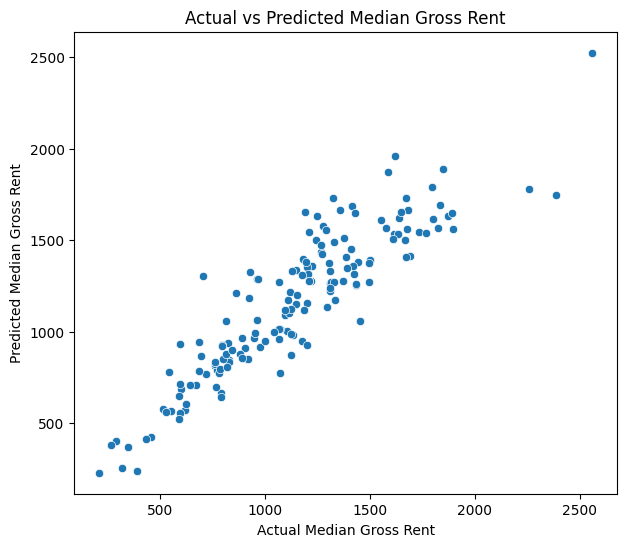

In [15]:
# plot actual vs predicted rent

plt.figure(figsize=(7,6))
sns.scatterplot(data=actual_vs_predicted, x='actual_rent', y='predicted_rent')
plt.title('Actual vs Predicted Median Gross Rent')
plt.xlabel('Actual Median Gross Rent')
plt.ylabel('Predicted Median Gross Rent')
plt.show()

## **Actual vs Predicted Interpretation**

The actual vs predicted plot shows how close the model predictions are to the real rent values.

The closer the points are to a diagonal pattern, the better the model is doing. The model does a strong job overall, but it still has errors. That makes sense because rent is shaped by many factors that are not fully captured in the dataset, like new development, zoning, amenities, landlord behavior, and local market conditions.


# **5. Regression Feature Importance**

Feature importance helps explain which variables the Random Forest used most when predicting median gross rent.


In [16]:
# feature importance from tuned random forest regressor

reg_feature_names = best_reg_model.named_steps['preprocess'].get_feature_names_out()
reg_importances = best_reg_model.named_steps['model'].feature_importances_

reg_feature_importance = pd.DataFrame({
    'Feature': reg_feature_names,
    'Importance': reg_importances
}).sort_values(by='Importance', ascending=False)

reg_feature_importance['Clean Feature'] = (
    reg_feature_importance['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
    .str.replace('year_cat_', 'year_', regex=False)
    .str.replace('distance_group_', 'distance_', regex=False)
)

reg_feature_importance.head(15)

,Feature,Importance,Clean Feature
0,num__median_income,0.564821,median_income
3,num__pct_renter,0.134790,pct_renter
7,cat__year_cat_2020,0.101610,year_2020
5,cat__year_cat_2000,0.045684,year_2000
4,num__centroid_distance_miles,0.045111,centroid_distance_miles
2,num__pct_black,0.043016,pct_black
1,num__poverty_rate,0.039415,poverty_rate
6,cat__year_cat_2010,0.011155,year_2010
11,cat__distance_group_1.5-3 miles,0.003718,distance_1.5-3 miles
10,cat__distance_group_1-1.5 miles,0.002608,distance_1-1.5 miles


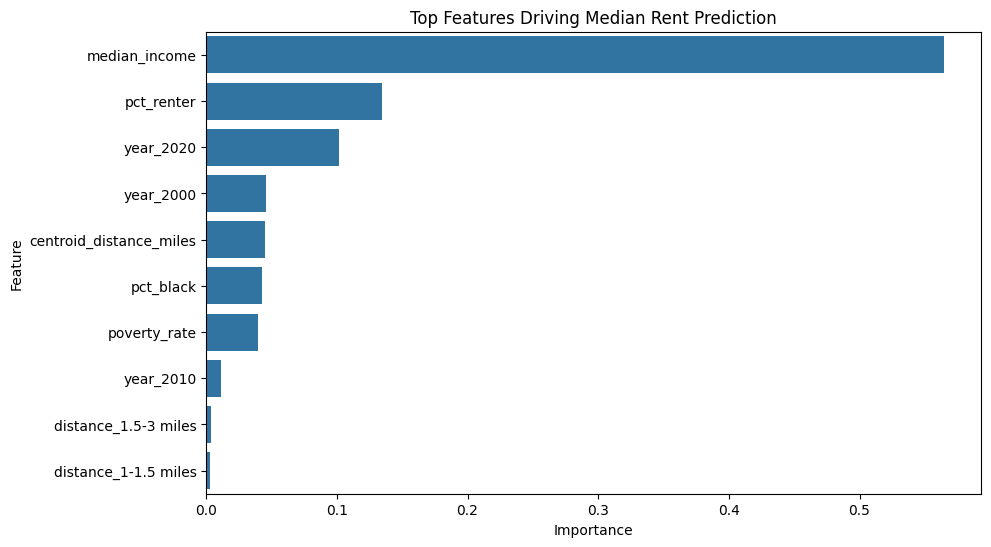

In [17]:
# plot regression feature importance

top_reg_features = reg_feature_importance.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_reg_features, x='Importance', y='Clean Feature')
plt.title('Top Features Driving Median Rent Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## **Regression Feature Importance Interpretation**

The most important feature for predicting actual rent was **median_income**, with an importance score of **0.565**.

The next strongest features were:

- **pct_renter**: 0.135
- **year_2020**: 0.102
- **year_2000**: 0.046
- **centroid_distance_miles**: 0.045

This makes sense for my capstone. Median income is the strongest driver, which shows that rent pressure is closely tied to neighborhood wealth. Year also matters because rent changed a lot from 2000 to 2020. Renter share, race, poverty, and distance from the BeltLine also remain part of the model, which connects back to the larger story of race, space, and redevelopment.


# **6. Regression Results by Year**

Since my capstone is about change over time, I also checked how the final regression model performed by year.


In [18]:
# regression performance by year

reg_test_results = X_reg_test.copy()
reg_test_results['actual_rent'] = y_reg_test
reg_test_results['predicted_rent'] = best_reg_pred

reg_year_eval = reg_test_results.groupby('year_cat').apply(
    lambda g: pd.Series({
        'RMSE': np.sqrt(mean_squared_error(g['actual_rent'], g['predicted_rent'])),
        'MAE': mean_absolute_error(g['actual_rent'], g['predicted_rent']),
        'R2': r2_score(g['actual_rent'], g['predicted_rent']) if len(g) > 1 else np.nan,
        'n': len(g)
    })
)

reg_year_eval

,RMSE,MAE,R2,n
year_cat,,,,
2000,113.584673,85.509540,0.685695,29.0
2010,98.752079,74.381720,0.787831,31.0
2020,215.111352,168.466667,0.596918,100.0


## **Regression by Year Interpretation**

The final regression model performed differently by year.

- In 2000, RMSE was **$114**
- In 2010, RMSE was **$99**
- In 2020, RMSE was **$215**

The 2020 error is higher because rent values are higher and more spread out in the most recent period. That makes sense because the housing market became more uneven over time.


# **7. Classification Modeling: Predicting High-Rent Tracts Within Each Year**

The second modeling task is classification.

Instead of predicting the exact rent amount, this model predicts whether a tract is high-rent compared to other tracts in the same year.

This gives a different but related angle on the same capstone question.


In [19]:
# create classification target

class_data = df[all_features + ['median_gross_rent', 'year']].replace([np.inf, -np.inf], np.nan).dropna(subset=['median_gross_rent']).copy()

# year-specific median rent
class_data['rent_year_median'] = class_data.groupby('year')['median_gross_rent'].transform('median')

# high rent compared to other tracts in the same year
class_data['high_rent_within_year'] = (
    class_data['median_gross_rent'] > class_data['rent_year_median']
).astype(int)

class_data[['year', 'median_gross_rent', 'rent_year_median', 'high_rent_within_year']].head()

,year,median_gross_rent,rent_year_median,high_rent_within_year
0,2000,808.0,617.0,1
1,2000,730.0,617.0,1
2,2000,691.0,617.0,1
3,2000,729.0,617.0,1
4,2000,530.0,617.0,0


In [20]:
# check class balance

class_data['high_rent_within_year'].value_counts()

,count
high_rent_within_year,
0,402
1,397


In [21]:
# class balance percentages

class_data['high_rent_within_year'].value_counts(normalize=True) * 100

,proportion
high_rent_within_year,
0,50.312891
1,49.687109


## **Classification Target Interpretation**

The classification target is balanced.

There are **402 lower-rent tracts** and **397 high-rent tracts**.

That means about **50.3%** of observations are lower-rent and **49.7%** are high-rent.

Because the classes are almost evenly split, I do not need SMOTE. I still use class weights in models where it makes sense because it is a safe way to reduce class bias.


In [22]:
# train/test split for classification

X_clf = class_data[all_features]
y_clf = class_data['high_rent_within_year']

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print('training rows:', X_clf_train.shape[0])
print('testing rows:', X_clf_test.shape[0])

training rows: 639
testing rows: 160


## **Classification Train/Test Split Interpretation**

For classification, I used an 80/20 split with stratification.

This created **639 training rows** and **160 testing rows**.

Using `stratify=y` keeps the high-rent and lower-rent classes balanced in the training and testing sets.


# **8. Classification Model Tournament**

I compared four classification models:

1. Logistic Regression  
2. K-Nearest Neighbors  
3. Decision Tree  
4. Random Forest  

This gives me a basic model tournament instead of relying on one algorithm.


In [23]:
# classification models

clf_models = {
    'Logistic Regression': Pipeline([
        ('preprocess', preprocess),
        ('model', LogisticRegression(
            max_iter=2000,
            class_weight='balanced'
        ))
    ]),

    'KNN': Pipeline([
        ('preprocess', preprocess),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),

    'Decision Tree': Pipeline([
        ('preprocess', preprocess),
        ('model', DecisionTreeClassifier(
            max_depth=5,
            random_state=42,
            class_weight='balanced'
        ))
    ]),

    'Random Forest': Pipeline([
        ('preprocess', preprocess),
        ('model', RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            random_state=42,
            class_weight='balanced'
        ))
    ])
}

In [24]:
# train and evaluate classification models

clf_results = []
clf_predictions = {}

for name, model in clf_models.items():
    model.fit(X_clf_train, y_clf_train)

    pred = model.predict(X_clf_test)
    prob = model.predict_proba(X_clf_test)[:, 1]

    clf_predictions[name] = pred

    clf_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_clf_test, pred),
        'Precision': precision_score(y_clf_test, pred),
        'Recall': recall_score(y_clf_test, pred),
        'F1 Score': f1_score(y_clf_test, pred),
        'ROC AUC': roc_auc_score(y_clf_test, prob)
    })

clf_results_df = pd.DataFrame(clf_results).sort_values(by='F1 Score', ascending=False)

clf_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.80625,0.800000,0.810127,0.805031,0.842319
1,KNN,0.79375,0.755556,0.860759,0.804734,0.833255
3,Random Forest,0.76875,0.738636,0.822785,0.778443,0.843726
2,Decision Tree,0.75625,0.763158,0.734177,0.748387,0.798719


## **Classification Model Interpretation**

The strongest baseline classification model by F1 score was **Logistic Regression**.

The baseline model results were:

- **Logistic Regression:** Accuracy = 0.806, F1 = 0.805
- **KNN:** Accuracy = 0.794, F1 = 0.805
- **Decision Tree:** Accuracy = 0.756, F1 = 0.748
- **Random Forest:** Accuracy = 0.769, F1 = 0.778

I am using F1 score because it balances precision and recall. Accuracy alone does not show whether the model is missing too many high-rent tracts.


# **9. Confusion Matrices and Classification Reports**

The confusion matrix shows how many tracts the model classified correctly and incorrectly.

For this classification task:

- `0` = lower rent compared to other tracts in the same year
- `1` = high rent compared to other tracts in the same year


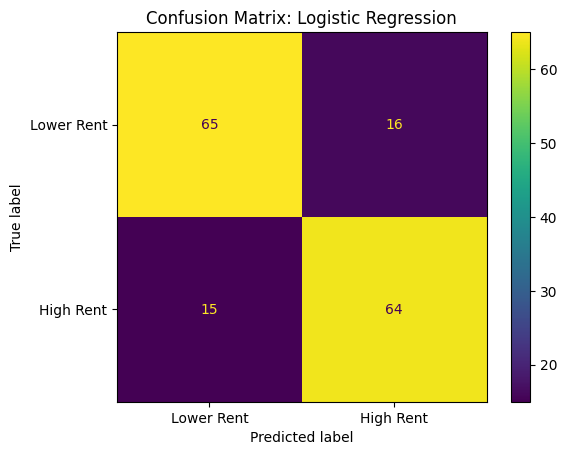

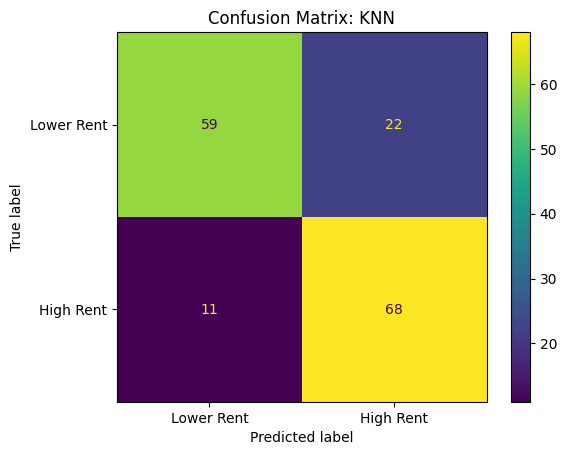

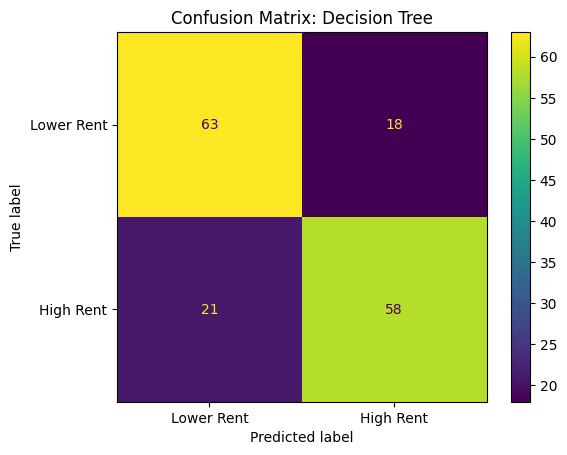

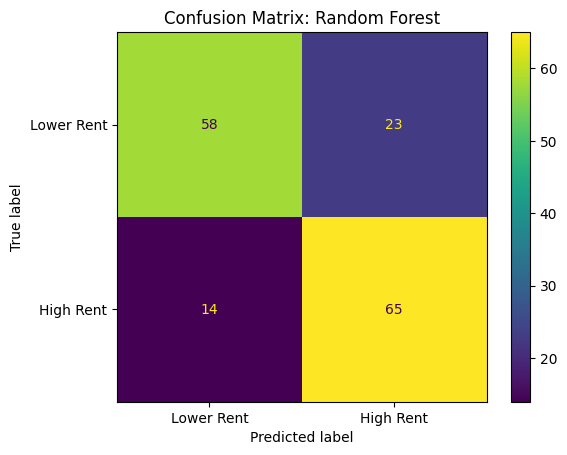

In [25]:
# confusion matrices

for name, model in clf_models.items():
    pred = model.predict(X_clf_test)

    cm = confusion_matrix(y_clf_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Lower Rent', 'High Rent']
    )

    disp.plot()
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

In [26]:
# classification reports

for name, model in clf_models.items():
    pred = model.predict(X_clf_test)

    print('\n==============================')
    print(name)
    print('==============================')
    print(classification_report(
        y_clf_test,
        pred,
        target_names=['Lower Rent', 'High Rent']
    ))


Logistic Regression
              precision    recall  f1-score   support

  Lower Rent       0.81      0.80      0.81        81
   High Rent       0.80      0.81      0.81        79

    accuracy                           0.81       160
   macro avg       0.81      0.81      0.81       160
weighted avg       0.81      0.81      0.81       160


KNN
              precision    recall  f1-score   support

  Lower Rent       0.84      0.73      0.78        81
   High Rent       0.76      0.86      0.80        79

    accuracy                           0.79       160
   macro avg       0.80      0.79      0.79       160
weighted avg       0.80      0.79      0.79       160


Decision Tree
              precision    recall  f1-score   support

  Lower Rent       0.75      0.78      0.76        81
   High Rent       0.76      0.73      0.75        79

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76

## **Confusion Matrix Interpretation**

For the baseline Logistic Regression model, the confusion matrix shows:

- True lower-rent tracts: **65**
- Lower-rent tracts incorrectly predicted as high-rent: **16**
- High-rent tracts incorrectly predicted as lower-rent: **15**
- True high-rent tracts: **64**

This matters because missing high-rent tracts would be a problem if the goal is to identify areas experiencing rent pressure.


# **10. Classification Hyperparameter Tuning**

I tested basic hyperparameter changes for Logistic Regression, KNN, Decision Tree, and Random Forest.

This shows how model settings affect performance.


In [27]:
# classification hyperparameter tuning

clf_tuning = []

# logistic regression tuning
for C in [0.1, 1, 10]:
    model = Pipeline([
        ('preprocess', preprocess),
        ('model', LogisticRegression(
            max_iter=2000,
            C=C,
            class_weight='balanced'
        ))
    ])

    model.fit(X_clf_train, y_clf_train)
    pred = model.predict(X_clf_test)
    prob = model.predict_proba(X_clf_test)[:, 1]

    clf_tuning.append({
        'Model': 'Logistic Regression',
        'C': C,
        'max_depth': None,
        'min_samples_leaf': None,
        'n_estimators': None,
        'n_neighbors': None,
        'Accuracy': accuracy_score(y_clf_test, pred),
        'Precision': precision_score(y_clf_test, pred),
        'Recall': recall_score(y_clf_test, pred),
        'F1 Score': f1_score(y_clf_test, pred),
        'ROC AUC': roc_auc_score(y_clf_test, prob)
    })

# knn tuning
for k in [3, 5, 7, 11]:
    model = Pipeline([
        ('preprocess', preprocess),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(X_clf_train, y_clf_train)
    pred = model.predict(X_clf_test)
    prob = model.predict_proba(X_clf_test)[:, 1]

    clf_tuning.append({
        'Model': 'KNN',
        'C': None,
        'max_depth': None,
        'min_samples_leaf': None,
        'n_estimators': None,
        'n_neighbors': k,
        'Accuracy': accuracy_score(y_clf_test, pred),
        'Precision': precision_score(y_clf_test, pred),
        'Recall': recall_score(y_clf_test, pred),
        'F1 Score': f1_score(y_clf_test, pred),
        'ROC AUC': roc_auc_score(y_clf_test, prob)
    })

# decision tree tuning
for depth in [3, 5, 8, None]:
    for leaf in [1, 5, 10, 20]:
        model = Pipeline([
            ('preprocess', preprocess),
            ('model', DecisionTreeClassifier(
                max_depth=depth,
                min_samples_leaf=leaf,
                random_state=42,
                class_weight='balanced'
            ))
        ])

        model.fit(X_clf_train, y_clf_train)
        pred = model.predict(X_clf_test)
        prob = model.predict_proba(X_clf_test)[:, 1]

        clf_tuning.append({
            'Model': 'Decision Tree',
            'C': None,
            'max_depth': depth,
            'min_samples_leaf': leaf,
            'n_estimators': None,
            'n_neighbors': None,
            'Accuracy': accuracy_score(y_clf_test, pred),
            'Precision': precision_score(y_clf_test, pred),
            'Recall': recall_score(y_clf_test, pred),
            'F1 Score': f1_score(y_clf_test, pred),
            'ROC AUC': roc_auc_score(y_clf_test, prob)
        })

# random forest tuning
for n in [100, 300]:
    for depth in [5, 8, 12, None]:
        for leaf in [1, 5, 10]:
            model = Pipeline([
                ('preprocess', preprocess),
                ('model', RandomForestClassifier(
                    n_estimators=n,
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    random_state=42,
                    class_weight='balanced'
                ))
            ])

            model.fit(X_clf_train, y_clf_train)
            pred = model.predict(X_clf_test)
            prob = model.predict_proba(X_clf_test)[:, 1]

            clf_tuning.append({
                'Model': 'Random Forest',
                'C': None,
                'max_depth': depth,
                'min_samples_leaf': leaf,
                'n_estimators': n,
                'n_neighbors': None,
                'Accuracy': accuracy_score(y_clf_test, pred),
                'Precision': precision_score(y_clf_test, pred),
                'Recall': recall_score(y_clf_test, pred),
                'F1 Score': f1_score(y_clf_test, pred),
                'ROC AUC': roc_auc_score(y_clf_test, prob)
            })

clf_tuning_df = pd.DataFrame(clf_tuning).sort_values(by='F1 Score', ascending=False)

clf_tuning_df.head(10)

,Model,C,max_depth,min_samples_leaf,n_estimators,n_neighbors,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.1,NaN,NaN,NaN,NaN,0.81250,0.810127,0.810127,0.810127,0.836850
1,Logistic Regression,1.0,NaN,NaN,NaN,NaN,0.80625,0.800000,0.810127,0.805031,0.842319
4,KNN,NaN,NaN,NaN,NaN,5.0,0.79375,0.755556,0.860759,0.804734,0.833255
31,Random Forest,NaN,12.0,10.0,100.0,NaN,0.79375,0.761364,0.848101,0.802395,0.840288
34,Random Forest,NaN,NaN,10.0,100.0,NaN,0.79375,0.761364,0.848101,0.802395,0.840288
23,Random Forest,NaN,5.0,1.0,100.0,NaN,0.79375,0.761364,0.848101,0.802395,0.849195
28,Random Forest,NaN,8.0,10.0,100.0,NaN,0.79375,0.761364,0.848101,0.802395,0.841225
37,Random Forest,NaN,5.0,10.0,300.0,NaN,0.79375,0.761364,0.848101,0.802395,0.843569
36,Random Forest,NaN,5.0,5.0,300.0,NaN,0.79375,0.761364,0.848101,0.802395,0.842632
27,Random Forest,NaN,8.0,5.0,100.0,NaN,0.78750,0.747253,0.860759,0.800000,0.847632


## **Classification Tuning Interpretation**

The best tuned classification model was **Logistic Regression**.

The tuned model reached:

- Accuracy = **0.812**
- Precision = **0.810**
- Recall = **0.810**
- F1 Score = **0.810**
- ROC AUC = **0.837**

This model balances precision and recall well. It does not only predict the majority class, which is important for this assignment.


In [28]:
# final tuned classification model

best_clf_model = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(
        max_iter=2000,
        C=0.1,
        class_weight='balanced'
    ))
])

best_clf_model.fit(X_clf_train, y_clf_train)

best_clf_pred = best_clf_model.predict(X_clf_test)
best_clf_prob = best_clf_model.predict_proba(X_clf_test)[:, 1]

print('Accuracy:', accuracy_score(y_clf_test, best_clf_pred))
print('Precision:', precision_score(y_clf_test, best_clf_pred))
print('Recall:', recall_score(y_clf_test, best_clf_pred))
print('F1 Score:', f1_score(y_clf_test, best_clf_pred))
print('ROC AUC:', roc_auc_score(y_clf_test, best_clf_prob))

confusion_matrix(y_clf_test, best_clf_pred)

Accuracy: 0.8125
Precision: 0.810126582278481
Recall: 0.810126582278481
F1 Score: 0.810126582278481
ROC AUC: 0.8368495077355836


array([[66, 15],
       [15, 64]])

## **Final Classification Model Interpretation**

The final tuned classification model correctly identified:

- **66 lower-rent tracts**
- **64 high-rent tracts**

It incorrectly classified:

- **15 lower-rent tracts as high-rent**
- **15 high-rent tracts as lower-rent**

This matters because the model missed **15 high-rent tracts**. In a displacement-pressure context, those false negatives matter because they are places the model failed to flag as high-rent.


# **11. Classification Feature Importance / Coefficients**

Since the best classifier is Logistic Regression, I used coefficients to understand which features pushed the prediction toward high-rent or lower-rent status.

I also include Random Forest feature importance as a second way to interpret the model.


In [29]:
# logistic regression coefficients

coef_names = best_clf_model.named_steps['preprocess'].get_feature_names_out()
coefs = best_clf_model.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': coef_names,
    'Coefficient': coefs,
    'Abs Coefficient': np.abs(coefs)
}).sort_values(by='Abs Coefficient', ascending=False)

coef_df['Clean Feature'] = (
    coef_df['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
    .str.replace('year_cat_', 'year_', regex=False)
    .str.replace('distance_group_', 'distance_', regex=False)
)

coef_df.head(15)

,Feature,Coefficient,Abs Coefficient,Clean Feature
0,num__median_income,1.026379,1.026379,median_income
7,cat__year_cat_2020,-0.549586,0.549586,year_2020
1,num__poverty_rate,-0.540975,0.540975,poverty_rate
5,cat__year_cat_2000,0.507608,0.507608,year_2000
2,num__pct_black,-0.458429,0.458429,pct_black
3,num__pct_renter,-0.138108,0.138108,pct_renter
13,cat__distance_group_3-5 miles,-0.126414,0.126414,distance_3-5 miles
14,cat__distance_group_5-10 miles,0.124739,0.124739,distance_5-10 miles
4,num__centroid_distance_miles,0.099269,0.099269,centroid_distance_miles
9,cat__distance_group_0.5-1 mile,-0.098975,0.098975,distance_0.5-1 mile


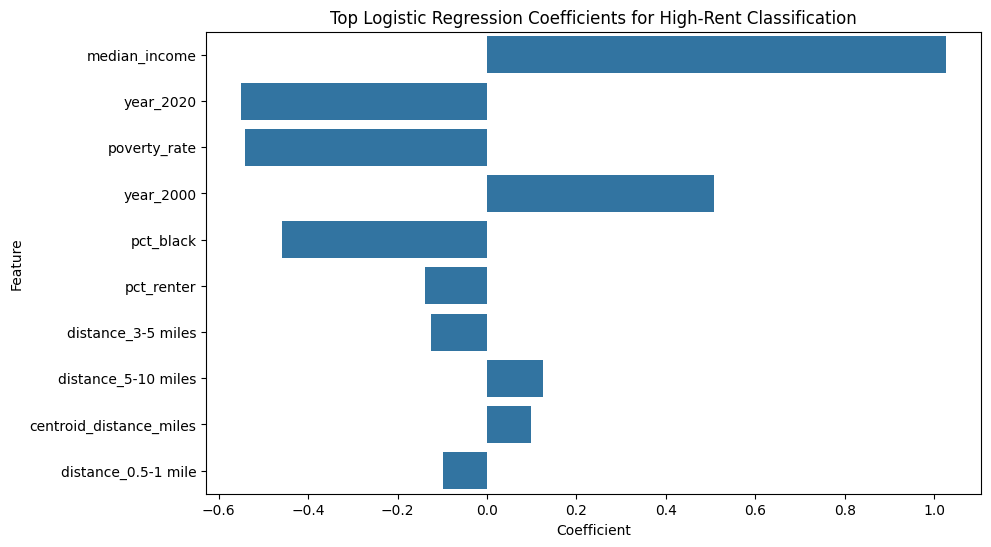

In [30]:
# plot logistic regression coefficients

top_coef = coef_df.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_coef, x='Coefficient', y='Clean Feature')
plt.title('Top Logistic Regression Coefficients for High-Rent Classification')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.show()

## **Classification Coefficient Interpretation**

The largest coefficient by absolute value was **median_income**, with a coefficient of **1.026**.

The next strongest coefficients were:

- **year_2020**: -0.550
- **poverty_rate**: -0.541
- **year_2000**: 0.508
- **pct_black**: -0.458

Positive coefficients push the model toward predicting high rent. Negative coefficients push the model toward predicting lower rent.

This connects back to the capstone because the model is not just making predictions. It is also showing which neighborhood conditions are most connected to rent pressure.


In [31]:
# random forest feature importance for classification

rf_clf = clf_models['Random Forest']
rf_clf.fit(X_clf_train, y_clf_train)

clf_rf_feature_names = rf_clf.named_steps['preprocess'].get_feature_names_out()
clf_rf_importances = rf_clf.named_steps['model'].feature_importances_

clf_rf_importance = pd.DataFrame({
    'Feature': clf_rf_feature_names,
    'Importance': clf_rf_importances
}).sort_values(by='Importance', ascending=False)

clf_rf_importance['Clean Feature'] = (
    clf_rf_importance['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
    .str.replace('year_cat_', 'year_', regex=False)
    .str.replace('distance_group_', 'distance_', regex=False)
)

clf_rf_importance.head(15)

,Feature,Importance,Clean Feature
0,num__median_income,0.255182,median_income
2,num__pct_black,0.204217,pct_black
1,num__poverty_rate,0.199997,poverty_rate
3,num__pct_renter,0.149194,pct_renter
4,num__centroid_distance_miles,0.088564,centroid_distance_miles
7,cat__year_cat_2020,0.025746,year_2020
5,cat__year_cat_2000,0.020398,year_2000
6,cat__year_cat_2010,0.011381,year_2010
14,cat__distance_group_5-10 miles,0.009220,distance_5-10 miles
12,cat__distance_group_10+ miles,0.008886,distance_10+ miles


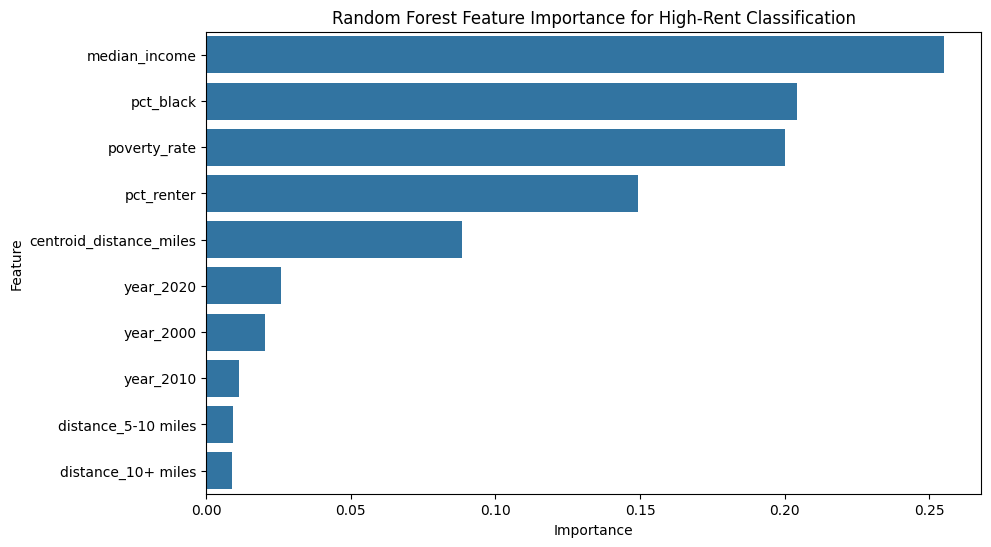

In [32]:
# plot random forest feature importance for classification

top_clf_rf = clf_rf_importance.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_clf_rf, x='Importance', y='Clean Feature')
plt.title('Random Forest Feature Importance for High-Rent Classification')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# **Final Summary**

This notebook uses both regression and classification to model rent pressure in Atlanta.

## Regression Takeaway
The main model predicts actual median gross rent. The tuned Random Forest Regressor performed best with an R² above 0.81, meaning the model explains a strong share of the variation in rent.

This is the model most aligned with my capstone because my original analysis focused on predicting and explaining continuous rent values.

## Classification Takeaway
The classification model predicts whether a tract is high-rent compared to other tracts in the same year. The tuned Logistic Regression model had an F1 score around 0.81, which shows solid performance while still being interpretable.

## Overall Capstone Connection
The strongest predictors were income, year, renter share, poverty, percent Black, and BeltLine distance. This supports the larger argument of my capstone: rent pressure is connected to economic conditions, racial composition, time, and space.

The model is not just predicting rent. It is helping explain which neighborhood features are most connected to rising housing costs and displacement pressure around the BeltLine.


# **GitHub / Portfolio Notes**

Suggested file name:

```text
BeltLine_Machine_Learning.ipynb
```

Suggested README link:

```markdown
[View BeltLine Machine Learning Notebook](BeltLine_Machine_Learning.ipynb)
```

To show outputs on GitHub:

1. Open this notebook in Google Colab.
2. Run all cells.
3. Save a copy back to GitHub.
4. Open the notebook in GitHub and make sure the tables, charts, confusion matrices, and outputs are visible.
